In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [6]:

file_path = '/content/Nutrition__Physical_Activity__and_Obesity_-_Behavioral_Risk_Factor_Surveillance_System.csv'
df = pd.read_csv(file_path, low_memory=False)

#filter only for the overall state totals (removes age/demographic splits)

cleaned_df = df[df['Stratification1'] == 'Total']

#pivots every single question from all years into its own column
cleaned_df1 = cleaned_df.pivot_table(
    index='LocationDesc',#all 50 states and territories
    columns='Question', #unique questions
    values='Data_Value',#percentage
    aggfunc='mean'
)

#remove empty rows
cleaned_df1 = cleaned_df1.dropna(how='all', axis=0)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
display(cleaned_df1)

cleaned_df1.to_csv('cleaned_df1.csv')

Question,Percent of adults aged 18 years and older who have an overweight classification,Percent of adults aged 18 years and older who have obesity,Percent of adults who achieve at least 150 minutes a week of moderate-intensity aerobic physical activity or 75 minutes a week of vigorous-intensity aerobic activity (or an equivalent combination),Percent of adults who achieve at least 150 minutes a week of moderate-intensity aerobic physical activity or 75 minutes a week of vigorous-intensity aerobic physical activity (or an equivalent combination) and engage in muscle-strengthening activities on 2 or more days a week,Percent of adults who achieve more than 300 minutes a week of moderate-intensity aerobic physical activity or 150 minutes a week of vigorous-intensity aerobic activity (or an equivalent combination),Percent of adults who engage in muscle-strengthening activities on 2 or more days a week,Percent of adults who engage in no leisure-time physical activity,Percent of adults who report consuming fruit less than one time daily,Percent of adults who report consuming vegetables less than one time daily
LocationDesc,,,,,,,,,
Alabama,33.764286,36.150000,46.233333,17.716667,28.433333,27.483333,30.035714,45.633333,20.733333
Alaska,35.707143,30.950000,58.683333,26.350000,39.050000,36.716667,20.507143,40.700000,18.900000
Arizona,35.285714,29.657143,54.833333,24.816667,35.550000,34.716667,23.128571,39.100000,21.466667
Arkansas,33.542857,36.214286,46.166667,18.116667,29.933333,28.116667,31.521429,45.866667,20.666667
California,35.750000,26.192857,57.750000,24.550000,36.716667,34.333333,20.864286,34.966667,22.600000
Colorado,35.664286,22.850000,61.300000,28.166667,40.200000,37.750000,17.092857,36.100000,18.566667
Connecticut,36.028571,27.692857,53.600000,24.033333,33.616667,34.666667,22.907143,33.866667,19.100000
Delaware,35.314286,32.728571,50.750000,22.350000,32.433333,33.133333,26.442857,37.366667,19.333333
District of Columbia,31.471429,23.478571,57.650000,27.033333,34.966667,37.466667,18.057143,33.133333,15.733333


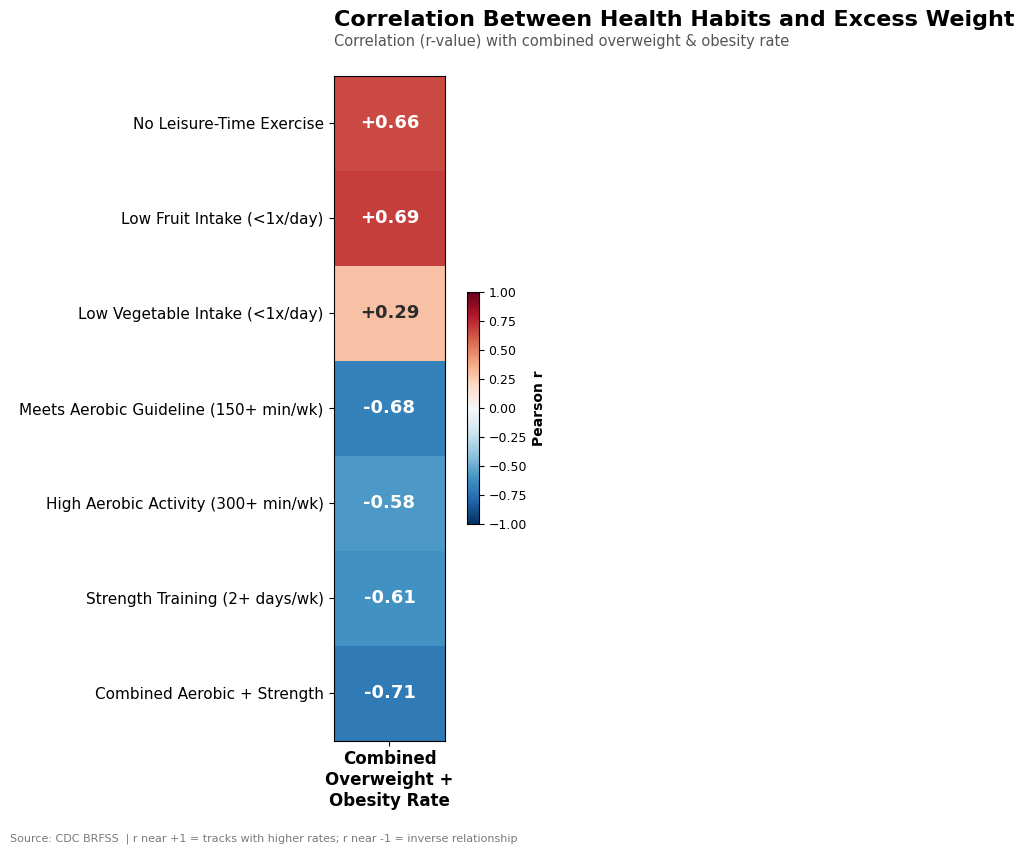

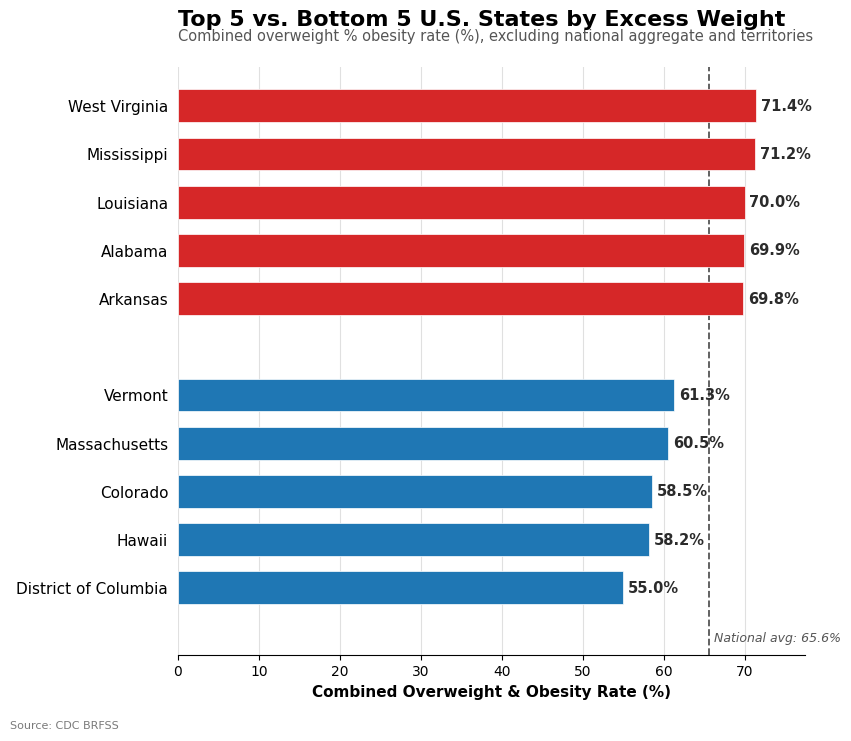

In [8]:
##renames columns to make them shorter and more readable
rename_map = {
    "Percent of adults aged 18 years and older who have an overweight classification": "Overweight Rate (%)",
    "Percent of adults aged 18 years and older who have obesity": "Obesity Rate (%)",
    "Percent of adults who engage in no leisure-time physical activity": "No Leisure-Time Exercise",
    "Percent of adults who report consuming fruit less than one time daily": "Low Fruit Intake (<1x/day)",
    "Percent of adults who report consuming vegetables less than one time daily": "Low Vegetable Intake (<1x/day)",
    "Percent of adults who achieve at least 150 minutes a week of moderate-intensity aerobic physical activity or 75 minutes a week of vigorous-intensity aerobic activity (or an equivalent combination)": "Meets Aerobic Guideline (150+ min/wk)",
    "Percent of adults who achieve more than 300 minutes a week of moderate-intensity aerobic physical activity or 150 minutes a week of vigorous-intensity aerobic activity (or an equivalent combination)": "High Aerobic Activity (300+ min/wk)",
    "Percent of adults who engage in muscle-strengthening activities on 2 or more days a week": "Strength Training (2+ days/wk)",
    "Percent of adults who achieve at least 150 minutes a week of moderate-intensity aerobic physical activity or 75 minutes a week of vigorous-intensity aerobic physical activity (or an equivalent combination) and engage in muscle-strengthening activities on 2 or more days a week": "Combined Aerobic + Strength",
}

#isolate state rows and drop national aggregate data
cleaned_df1 = cleaned_df1.rename(columns=rename_map)
locations = cleaned_df1.drop(index="National") if "National" in cleaned_df1.index else cleaned_df1.copy()

#define all target columns
all_habit_cols = [
    "No Leisure-Time Exercise",
    "Low Fruit Intake (<1x/day)",
    "Low Vegetable Intake (<1x/day)",
    "Meets Aerobic Guideline (150+ min/wk)",
    "High Aerobic Activity (300+ min/wk)",
    "Strength Training (2+ days/wk)",
    "Combined Aerobic + Strength",
]

habit_cols = [c for c in all_habit_cols if c in locations.columns]

#combine overweight and obesity rates
locations["Combined Overweight & Obesity (%)"] = (
    locations["Overweight Rate (%)"] + locations["Obesity Rate (%)"]
)

#overwrite columns for final chart mapping
outcome_cols = ["Combined Overweight & Obesity (%)"]
outcome_labels = {"Combined Overweight & Obesity (%)": "Combined\nOverweight +\nObesity Rate"}

#Chart 1: Heatmap

#generates correlation matrix between habits and excess weight
corr = pd.DataFrame(index=habit_cols, columns=outcome_cols, dtype=float)
for h in habit_cols:
    for o in outcome_cols:
        corr.loc[h, o] = locations[h].corr(locations[o])

row_labels = habit_cols
col_labels = [outcome_labels[o] for o in outcome_cols]

fig, ax = plt.subplots(figsize=(5.5, 0.9 * len(habit_cols) + 2))

data = corr.values.astype(float)
im = ax.imshow(data, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')

ax.set_xticks(np.arange(len(col_labels)))
ax.set_xticklabels(col_labels, fontsize=12, fontweight='bold')
ax.set_yticks(np.arange(len(row_labels)))
ax.set_yticklabels(row_labels, fontsize=11)
ax.grid(False)

#overlay r values inside blocks
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        val = data[i, j]
        text_color = 'white' if abs(val) > 0.55 else '#2b2b2b'
        ax.text(j, i, f"{val:+.2f}", ha='center', va='center',
                fontsize=13, fontweight='bold', color=text_color)

#add colorbar legend
cbar = fig.colorbar(im, ax=ax, fraction=0.08, pad=0.15, shrink=0.85)
cbar.set_label('Pearson r', fontsize=10, fontweight='bold')
cbar.ax.tick_params(labelsize=9)

#titles and footnotes
ax.set_title("Correlation Between Health Habits and Excess Weight", fontsize=16, fontweight='bold', pad=36, loc='left')
ax.text(0, 1.045, "Correlation (r-value) with combined overweight & obesity rate",
        transform=ax.transAxes, fontsize=10.5, color='#555555', ha='left')

fig.text(0.01, -0.02,
         "Source: CDC BRFSS  | r near +1 = tracks with higher rates; r near -1 = inverse relationship",
         fontsize=8, color='#7a7a7a', ha='left')

#save and render correlation heatmap
plt.tight_layout()
plt.savefig("health_habits_correlation_heatmap.png", dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

#Chart 2: top 5 and bottom 5 states in terms of obesity and overweight rates

#isolate top 5 and bottom 5 states
sorted_combined = locations["Combined Overweight & Obesity (%)"].sort_values(ascending=False)
top5 = sorted_combined.head(5)
bottom5 = sorted_combined.tail(5).sort_values(ascending=False)

#combine datasets
combined_group = pd.concat([top5, bottom5])
labels = list(combined_group.index)
values = combined_group.values
colors = ['#d62728'] * 5 + ['#1f77b4'] * 5  # red = highest, blue = lowest
y_pos = np.array([9, 8, 7, 6, 5, 3, 2, 1, 0, -1])

#generate horizontal bar chart
fig, ax = plt.subplots(figsize=(8.5, 7.2))
ax.barh(y_pos, values, color=colors, height=0.68, edgecolor='white', linewidth=0.5, zorder=3)

#print vals for the tip of each bar
for y, v in zip(y_pos, values):
    ax.text(v + 0.6, y, f"{v:.1f}%", va='center', ha='left', fontsize=10.5, fontweight='bold', color='#2b2b2b')

ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=11)

#plot national average line
if "National" in cleaned_df1.index:
    national_val = (
        cleaned_df1.loc["National", "Overweight Rate (%)"]
        + cleaned_df1.loc["National", "Obesity Rate (%)"]
    )
    ax.axvline(national_val, color='#555555', linestyle='--', linewidth=1.3, zorder=2)
    ax.text(national_val + 0.6, -1.9, f"National avg: {national_val:.1f}%",
            fontsize=9, color='#555555', ha='left', va='top', style='italic')

#clean layout bounderies and lines
ax.set_xlim(0, max(values) + 6)
ax.set_ylim(-2.4, 9.8)
ax.set_xlabel("Combined Overweight & Obesity Rate (%)", fontsize=11, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.grid(axis='x', color='#e0e0e0', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.tick_params(left=False)

#chart headers
ax.set_title("Top 5 vs. Bottom 5 U.S. States by Excess Weight", fontsize=16, fontweight='bold', pad=30, loc='left')
ax.text(0, 1.045, "Combined overweight % obesity rate (%), excluding national aggregate and territories",
        transform=ax.transAxes, fontsize=10.5, color='#555555', ha='left')
fig.text(0.01, -0.02, "Source: CDC BRFSS", fontsize=8, color='#7a7a7a', ha='left')

#save and export chart
plt.tight_layout()
plt.savefig("top_and_bottom_states_obesity.png", dpi=200, bbox_inches='tight', facecolor='white')
plt.show()